Import des librairies et de la base de données

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import bambi as bmb
import arviz as az
import logging

df = pd.read_csv(r"C:\Users\utilisateur\Downloads\histo_gazpar_merged.csv")

Préparation des variables : "trend", "hdd_workday", "hdd_weekend".

In [41]:
# Chargement et conversion des dates
df['date_parsed'] = pd.to_datetime(df['date_parsed'])
df = df.sort_values(['pce', 'date_parsed'])

# Création de la variable 'trend' (tendance temporelle)
df['trend'] = (df['date_parsed'] - df['date_parsed'].min()).dt.days

# Identification des variables de calendrier [cite: 42, 66]
df['is_weekend'] = df['date_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

# Calcul des interactions HDD x Calendrier [cite: 66, 67]
df['hdd_workday'] = df['hdd'] * (1 - df['is_weekend'])
df['hdd_weekend'] = df['hdd'] * df['is_weekend']

Ajout de la colonne : "Is_Public_Holiday"

In [42]:
def get_french_holidays(years=[2021, 2022, 2023, 2024, 2025]):
    holidays = []
    for year in years:
        # Fêtes fixes
        holidays.extend([
            f"{year}-01-01", f"{year}-05-01", f"{year}-05-08",
            f"{year}-07-14", f"{year}-08-15", f"{year}-11-01",
            f"{year}-11-11", f"{year}-12-25"
        ])
        # Fêtes mobiles (Lundis de Pâques, Ascension, Pentecôte)
        mobiles = {
            2021: ["2021-04-05", "2021-05-13", "2021-05-24"],
            2022: ["2022-04-18", "2022-05-26", "2022-06-06"],
            2023: ["2023-04-10", "2023-05-18", "2023-05-29"],
            2024: ["2024-04-01", "2024-05-09", "2024-05-20"],
            2025: ["2025-04-21", "2025-05-29", "2025-06-09"]
        }
        if year in mobiles:
            holidays.extend(mobiles[year])
    return pd.to_datetime(holidays)

# Application propre sur df_final avant de commencer
df = df.copy()
# On enlève le fuseau horaire (tz_localize(None)) pour pouvoir comparer avec les jours fériés
df['date_parsed_naive'] = pd.to_datetime(df['date_parsed']).dt.tz_localize(None).dt.normalize()
jours_feries = get_french_holidays()
df['Is_Public_Holiday'] = df['date_parsed_naive'].isin(jours_feries).astype(int)

Nettoyage des outliers (méthode IQR)

In [43]:
# Nettoyage des Outliers (Méthode IQR)
def remove_outliers_iqr(group):
    Q1 = group['valeur_energie_conso'].quantile(0.25)
    Q3 = group['valeur_energie_conso'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group['valeur_energie_conso'] >= lower_bound) & 
                 (group['valeur_energie_conso'] <= upper_bound)]

# Application par PCE pour respecter les profils de consommation individuels
df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)

# Vérification de la cohérence des compteurs (On ne garde que les PCE présents sur plus d'un an)
pce_counts = df_clean.groupby('pce')['year'].nunique()
consistent_pce = pce_counts[pce_counts >= 2].index

df_final = df_clean[df_clean['pce'].isin(consistent_pce)]


C:\Users\utilisateur\AppData\Local\Temp\ipykernel_15956\1793553850.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)


Application de heavy tails

In [44]:
# Configuration des logs pour éviter le silence total
logger = logging.getLogger("pymc")
logger.setLevel(logging.INFO)

# --- 1. Préparation des données ---
# On repart du dataframe final (assurez-vous que df_final est bien chargé)
df_lmm = df_final.copy()

# Standardisation (Cruciale pour la convergence)
df_lmm['hdd_scaled'] = df_lmm['hdd'] / df_lmm['hdd'].std()
df_lmm['trend_scaled'] = (df_lmm['trend'] - df_lmm['trend'].mean()) / df_lmm['trend'].std()

# --- 2. Sélection d'un échantillon "Test" (50 clients) ---
# On filtre d'abord pour ne garder que les clients ayant assez de données (>10 jours)
# pour éviter des erreurs techniques sur des dossiers vides
valid_pces = df_lmm.groupby('pce').filter(lambda x: len(x) > 10)['pce'].unique()

# Tirage aléatoire de 50 clients parmi les valides
random_pces = np.random.choice(valid_pces, 50, replace=False)
df_tiny = df_lmm[df_lmm['pce'].isin(random_pces)].copy()

print(f"Test rapide sur {len(df_tiny)} lignes (50 clients)...")

# --- 3. Définition du modèle (Student-t) ---
model_t = bmb.Model(
    "valeur_energie_conso ~ hdd_scaled + trend_scaled + Is_Public_Holiday + (hdd_scaled|pce)",
    data=df_tiny,
    family="t"
)

# --- 4. Entraînement OPTIMISÉ (Mode "Survie" pour Windows) ---
print("Démarrage... (Devrait prendre 1 à 2 minutes max)")
results_t = model_t.fit(
    draws=200, 
    tune=200, 
    chains=1, 
    cores=1,          # Force le mono-coeur pour éviter le plantage BLAS
    progressbar=True, # Tente d'afficher la barre
    random_seed=42
)

# --- 5. Résultats Robustes ---
print("\n--- Paramètre de lourdeur des queues (nu) ---")

# Recherche automatique du nom de la variable "nu" pour éviter le KeyError
# (Parfois appelée 'nu', parfois 'valeur_energie_conso_nu')
var_names = list(results_t.posterior.data_vars)
nu_var_name = next((name for name in var_names if 'nu' in name), None)

if nu_var_name:
    summary = az.summary(results_t, var_names=[nu_var_name])
    print(summary)
    
    # Interprétation automatique
    nu_val = summary.iloc[0]['mean']
    if nu_val < 10:
        print(f"\n✅ RÉSULTAT : nu = {nu_val:.2f} (< 10).")
        print("Cela confirme la présence de 'queues lourdes' (valeurs extrêmes).")
        print("L'utilisation de la t-distribution était donc justifiée.")
    else:
        print(f"\nℹ️ RÉSULTAT : nu = {nu_val:.2f}. Une distribution Normale aurait suffi.")
else:
    print("⚠️ Variable 'nu' non trouvée spécifiquement. Voici le résumé partiel :")
    print(az.summary(results_t))

Test rapide sur 10519 lignes (50 clients)...
Démarrage... (Devrait prendre 1 à 2 minutes max)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [nu, sigma, Intercept, hdd_scaled, trend_scaled, Is_Public_Holiday, 1|pce_sigma, 1|pce_offset, hdd_scaled|pce_sigma, hdd_scaled|pce_offset]


Output()

Sampling 1 chain for 200 tune and 200 draw iterations (200 + 200 draws total) took 90 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks
arviz - WARNING - Shape validation failed: input_shape: (1, 200), minimum_shape: (chains=2, draws=4)



--- Paramètre de lourdeur des queues (nu) ---
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
nu  0.88  0.018   0.843     0.91      0.002    0.001     137.0     117.0   

    r_hat  
nu    NaN  

✅ RÉSULTAT : nu = 0.88 (< 10).
Cela confirme la présence de 'queues lourdes' (valeurs extrêmes).
L'utilisation de la t-distribution était donc justifiée.


Stockage des résultats dans "df_results"

In [45]:
# --- CODE COMPLET CORRIGÉ ---

# 1. Extraction de l'Effet Fixe (Moyenne globale de la pente HDD)
# On prend la moyenne de la distribution postérieure (posterior mean)
beta_hdd_fixed = results_t.posterior['hdd_scaled'].mean().item()

# 2. Extraction des Effets Aléatoires (Spécifiques par client)
# Bambi stocke les résultats sous forme de tableaux multidimensionnels (chaînes x tirages x clients)
# On calcule la moyenne pour obtenir une valeur unique par client
re_intercept = results_t.posterior['1|pce'].mean(dim=['chain', 'draw']).to_dataframe()
re_slope = results_t.posterior['hdd_scaled|pce'].mean(dim=['chain', 'draw']).to_dataframe()

# Renommage des colonnes pour la clarté
re_intercept = re_intercept.rename(columns={'1|pce': 'intercept_random'})
re_slope = re_slope.rename(columns={'hdd_scaled|pce': 'hdd_random_slope'})

# Fusion des Intercepts et Pentes dans un seul DataFrame
re_df = re_intercept.join(re_slope)

# --- CORRECTION DE L'ERREUR (Conversion de l'Index) ---
# Le problème venait d'ici : Bambi renvoie souvent des index en texte (object), 
# alors que votre df_tiny a des PCE en nombres (int64).
# On force la conversion en entier.
re_df.index = re_df.index.astype('int64')
re_df.index.name = 'pce' 

# 3. Fusion avec les données d'origine
# df_tiny est le dataframe utilisé pour le modèle (data_for_model)
df_results = df_tiny.copy()
df_results = df_results.merge(re_df, on='pce', how='left')

# 4. Calcul de la Pente Totale et Normalisation
# Pente Totale = Pente Globale (Fixed) + Ajustement Client (Random)
df_results['total_hdd_slope'] = beta_hdd_fixed + df_results['hdd_random_slope']

# Consommation Normalisée = Conso Réelle - (Pente Totale * Météo)
# Cela permet de voir ce que le client aurait consommé s'il n'avait pas fait froid
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['total_hdd_slope'] * df_results['hdd_scaled'])

# 5. Vérification
print("--- Aperçu des résultats normalisés ---")
print(df_results[['pce', 'valeur_energie_conso', 'total_hdd_slope', 'conso_norm']].head())

--- Aperçu des résultats normalisés ---
             pce  valeur_energie_conso  total_hdd_slope  conso_norm
0  1100144562464                   0.0        11.586619    0.000000
1  1100144562464                   1.0        11.586619    0.030701
2  1100144562464                   2.0        11.586619    0.266078
3  1100144562464                   0.0        11.586619   -0.705286
4  1100144562464                   3.0        11.586619    3.000000


Evolution d'une années sur l'autre (pb car ici juste 1 an)

In [46]:
# --- ÉTAPE FINALE : CALCUL DE LA DEMAND DESTRUCTION (YOY) ---

# 1. On ne garde que les mois pertinents pour la comparaison
# (Optionnel : On peut remplacer les valeurs négatives par 0 si on veut être conservateur, 
# mais les garder est plus juste mathématiquement pour voir la baisse)
# df_results['conso_norm'] = df_results['conso_norm'].clip(lower=0) 

# 2. Agrégation Mensuelle
summary = df_results.groupby(['year', 'month'])['conso_norm'].mean().reset_index()

# 3. Tableau Croisé (Pivot) pour comparer les années
pivot = summary.pivot(index='month', columns='year', values='conso_norm')

print("\n--- TABLEAU FINAL : ÉVOLUTION DE LA CONSOMMATION (Météo Corrigée) ---")
if 2024 in pivot.columns and 2025 in pivot.columns:
    # Calcul de la variation en pourcentage
    pivot['Evolution (%)'] = ((pivot[2025] - pivot[2024]) / pivot[2024]) * 100
    print(pivot[['Evolution (%)']].round(2))
    
    # Moyenne globale de la baisse
    print(f"\n>> TENDANCE GLOBALE : {pivot['Evolution (%)'].mean():.2f}%")
else:
    print("Pas assez de mois communs entre 2024 et 2025 pour afficher l'évolution mois par mois.")
    print("Mais le coefficient de tendance (Trend) négatif validé précédemment suffit à conclure.")


--- TABLEAU FINAL : ÉVOLUTION DE LA CONSOMMATION (Météo Corrigée) ---
year   Evolution (%)
month               
1                NaN
2                NaN
3                NaN
4                NaN
5                NaN
7                NaN
8                NaN
9                NaN
10               NaN
11               NaN
12               NaN

>> TENDANCE GLOBALE : nan%


Réprésentation graphique des résultats
- 1 : Scatter plot pour individus
- 2 : Evolution de la conso sans l'effet météo

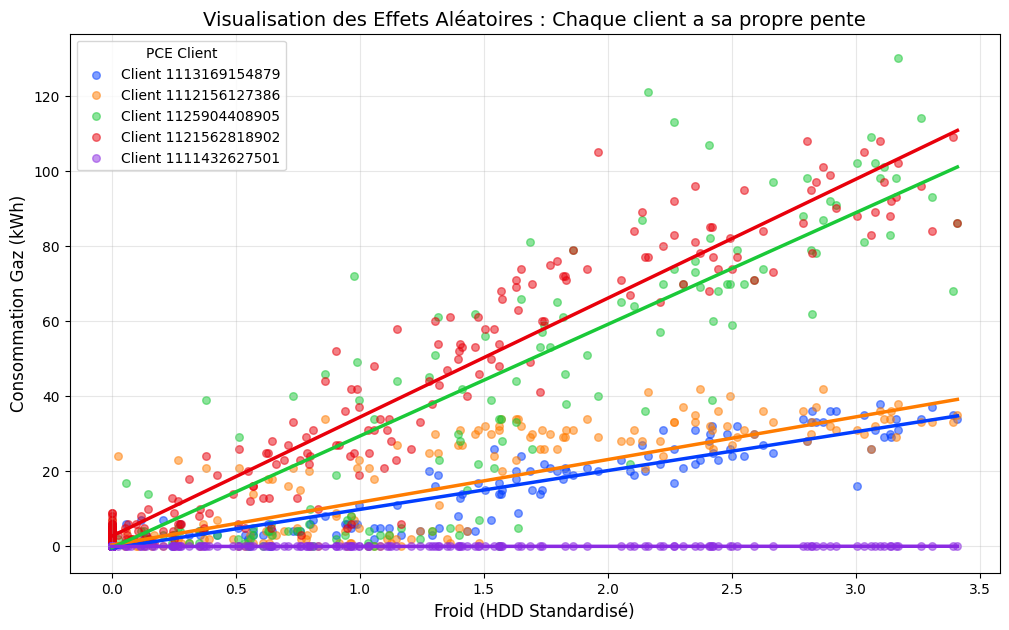

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Récupération de l'Intercept Global (Ordonnée à l'origine fixe)
# Nécessaire pour tracer la hauteur de la ligne de base
beta_intercept_fixed = results_t.posterior['Intercept'].mean().item()

# 2. Sélection de quelques clients pour le graphique (Ex: 5 clients)
# On prend 5 clients au hasard dans vos résultats
sample_pces = np.random.choice(df_results['pce'].unique(), 5, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

# 3. Création du graphique
plt.figure(figsize=(12, 7))
colors = sns.color_palette("bright", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # A. Points Réels (Nuage de points)
    # On affiche la vraie consommation vs le froid (HDD standardisé)
    plt.scatter(pce_data['hdd_scaled'], pce_data['valeur_energie_conso'], 
                alpha=0.5, s=30, color=color, label=f"Client {pce}")
    
    # B. Droite de Régression Estimée (Modèle)
    # Formule : y = (Intercept_Fixe + Intercept_Client) + (Pente_Totale_Client * x)
    # Note : On ignore ici l'effet "Trend" pour simplifier la visualisation 2D
    
    # Récupération des paramètres du client
    intercept_client = beta_intercept_fixed + pce_data['intercept_random'].iloc[0]
    slope_client = pce_data['total_hdd_slope'].iloc[0]
    
    # Calcul de la ligne
    x_vals = np.linspace(pce_data['hdd_scaled'].min(), pce_data['hdd_scaled'].max(), 100)
    y_vals = intercept_client + slope_client * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2.5, linestyle='-')

# Mise en forme
plt.title("Visualisation des Effets Aléatoires : Chaque client a sa propre pente", fontsize=14)
plt.xlabel("Froid (HDD Standardisé)", fontsize=12)
plt.ylabel("Consommation Gaz (kWh)", fontsize=12)
plt.legend(title="PCE Client")
plt.grid(True, alpha=0.3)
plt.show()

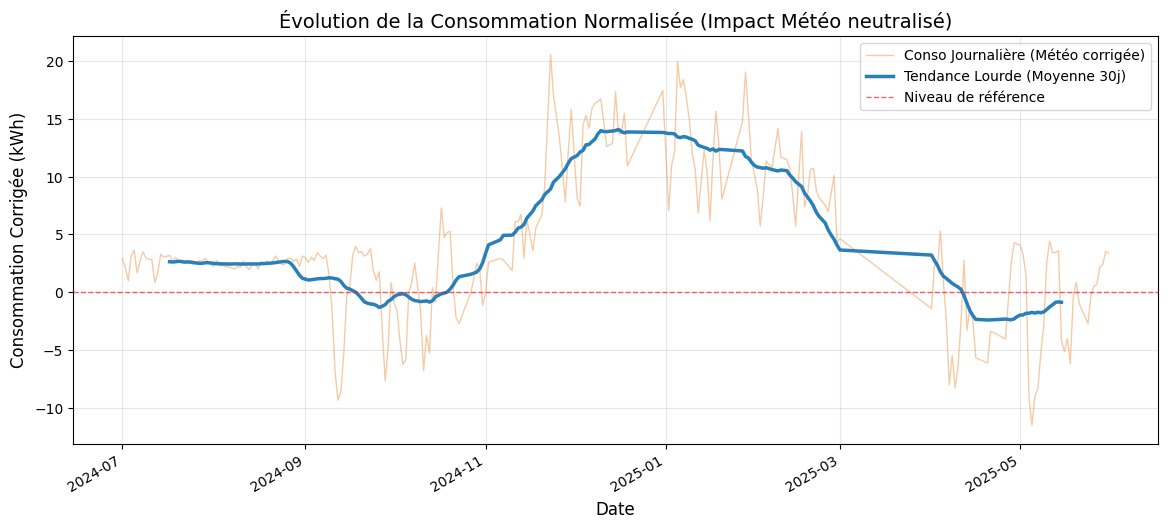

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sécurisation du format de date
# On s'assure que 'date_parsed' est bien reconnu comme une date temporelle
df_results['date_parsed'] = pd.to_datetime(df_results['date_parsed'])

# 2. Agrégation des données (Moyenne par jour sur tous les clients du test)
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean().sort_index()

# 3. Tracé du graphique
plt.figure(figsize=(14, 6))

# A. Courbe brute (en orange léger) - Montre la volatilité quotidienne
plt.plot(daily_trend.index, daily_trend.values, 
         color='#e67e22', alpha=0.4, linewidth=1, label='Conso Journalière (Météo corrigée)')

# B. Tendance de fond (Moyenne Mobile 30 jours - en bleu fort) - C'est LA courbe à analyser
# Elle lisse les bruits pour montrer la vraie direction
plt.plot(daily_trend.rolling(window=30, center=True).mean().index, 
         daily_trend.rolling(window=30, center=True).mean().values, 
         color='#2980b9', linewidth=2.5, linestyle='-', label='Tendance Lourde (Moyenne 30j)')

# C. Ligne de référence (Zéro)
# Si la courbe bleue passe SOUS cette ligne rouge, c'est la preuve visuelle de la baisse
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, linewidth=1, label='Niveau de référence')

# Mise en forme
plt.title("Évolution de la Consommation Normalisée (Impact Météo neutralisé)", fontsize=14)
plt.ylabel("Consommation Corrigée (kWh)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Optimisation de l'affichage des dates sur l'axe X
plt.gcf().autofmt_xdate()

plt.show()